# 09 • Multimodal RAG: ค้นภาพด้วย Caption Embeddings

เป้าหมาย: ภาพ → LLM อธิบายภาพ → Text Embedding → บันทึก index → ค้นภาพต้นฉบับ → LLM ตอบจากภาพ

เป็นการค้นภาพผ่านคำบรรยาย ไม่ใช่การสร้าง image embedding โดยตรง หากคำบรรยายตกหล่นรายละเอียด การค้นหาอาจผิดพลาด

**ข้อมูลสมมติสำหรับอบรม:** ใช้ภาพเอกสารและผังคลังตัวอย่าง ไม่ใช่ข้อมูลหรือ SOP จริงของศรีตรัง บริบทธุรกิจ: https://www.sritranggroup.com/th/home

API reference: https://developers.openai.com/api/docs/guides/images-vision

## เตรียมพร้อมก่อนเริ่ม
เพิ่ม Secret ชื่อ `OPENAI_API_KEY` ใน Colab ด้วยตนเอง และเปิด **Notebook access** สำหรับ notebook นี้ โค้ดจะอ่านผ่าน `userdata.get()` โดยไม่แสดงค่า key

รันเซลล์จากบนลงล่าง หลังติดตั้ง package และเตรียม key แล้ว ทดสอบตัวอย่างหลักใน Colab ด้วย API แล้ว แต่ผล LLM อาจเปลี่ยนได้ การผ่านตัวอย่างนี้ไม่ใช่การรับรองทุกคำถามหรือการใช้งานจริง

ใช้ `gpt-4.1-mini` สำหรับสร้างคำตอบ (ไม่เกิน 500 tokens ต่อ request) และ `text-embedding-3-small` สำหรับ Embedding โดย Agent Loop จำกัดไว้ 5 รอบ

In [1]:
%pip -q install openai numpy pillow

In [2]:
from google.colab import userdata
from openai import OpenAI

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
MODEL = "gpt-4.1-mini"

## อัปโหลดภาพตัวอย่าง
เลือก PNG/JPEG 2–3 ภาพจาก materials/mock_images อัปโหลดผ่าน Files pane ทางซ้ายก่อนรันได้ โดยคงชื่อไฟล์ 01_, 02_, 03_ หรือใช้ปุ่มเลือกไฟล์ใน output

ภาพและ index เก็บใน runtime ดาวน์โหลด image_index.zip หากต้องการเก็บไว้ ภาพจะส่งเข้า OpenAI ตอนสร้างคำบรรยายและตอนตอบ ใช้เฉพาะข้อมูลสมมติในการอบรม

ภาพ 1 ไฟล์ต้นฉบับ: 01_latex_receipt.png


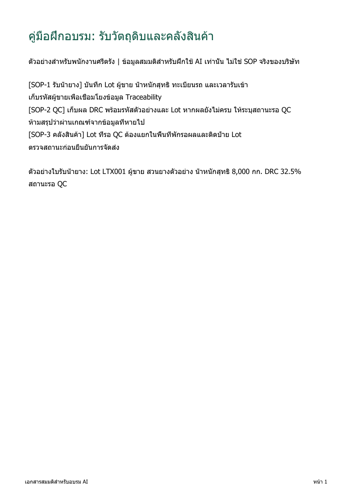

ภาพ 2 ไฟล์ต้นฉบับ: 02_warehouse_layout.png


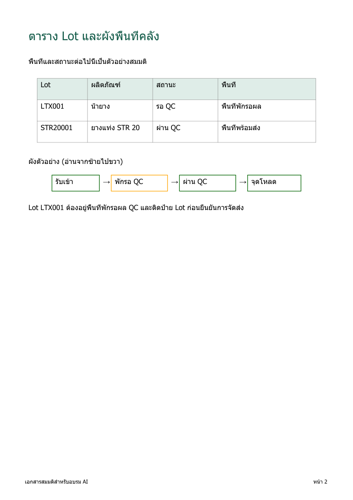

ภาพ 3 ไฟล์ต้นฉบับ: 03_coordination_sop.png


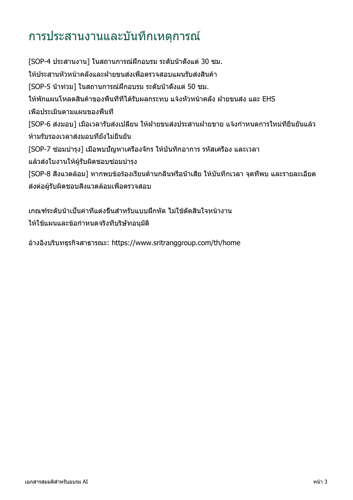

In [3]:
from google.colab import files
from pathlib import Path
from PIL import Image as PILImage
from IPython.display import display
import base64, json, hashlib, io
import numpy as np

folder = Path("image_index")
folder.mkdir(exist_ok=True)
# อัปโหลดภาพตัวอย่างผ่าน Files pane ก่อนรันได้
sample_paths = sorted(Path(".").glob("0[123]_*.png"))
uploaded = {p.name: p.read_bytes() for p in sample_paths} if sample_paths else files.upload()
if not 2 <= len(uploaded) <= 3:
    raise ValueError("เลือกภาพ PNG/JPEG จำนวน 2–3 ภาพ")
image_paths = []
for i, (name, data) in enumerate(uploaded.items(), 1):
    if Path(name).suffix.lower() not in {".png", ".jpg", ".jpeg"}:
        raise ValueError("รองรับเฉพาะ PNG/JPEG")
    path = folder / f"image_{i}.png"
    with PILImage.open(io.BytesIO(data)) as image:
        image.convert("RGB").save(path)
    image_paths.append(path)
    print("ภาพ", i, "ไฟล์ต้นฉบับ:", name)
    preview = PILImage.open(path)
    preview.thumbnail((360, 500))
    display(preview)

def image_content(path):
    encoded = base64.b64encode(Path(path).read_bytes()).decode()
    return {"type": "input_image", "image_url": "data:image/png;base64," + encoded,
            "detail": "high"}

In [4]:
EMBED_MODEL = "text-embedding-3-small"
caption_prompt = "อธิบายภาพเป็นภาษาไทยสำหรับใช้ค้นหา ระบุประเภทเอกสาร งานที่เกี่ยวข้อง ข้อความสำคัญ Lot สถานะ QC พื้นที่ และความสัมพันธ์ในผังเท่าที่เห็น หากอ่านไม่ชัดให้ระบุ ห้ามเดา"
records = []
for path in image_paths:
    response = client.responses.create(
        model=MODEL,
        input=[{"role": "user", "content": [
            {"type": "input_text", "text": caption_prompt}, image_content(path)
        ]}], max_output_tokens=500,
    )
    caption = response.output_text.strip()
    if not caption:
        raise ValueError("ไม่พบคำบรรยาย กรุณาตรวจ response ก่อนทำ index")
    records.append({"file": path.name, "caption": caption,
                    "sha256": hashlib.sha256(path.read_bytes()).hexdigest()})
    print(path.name, caption, "\n")

result = client.embeddings.create(model=EMBED_MODEL, input=[r["caption"] for r in records])
vectors = np.array([item.embedding for item in result.data])
vectors = vectors / np.linalg.norm(vectors, axis=1, keepdims=True)
(folder / "records.json").write_text(json.dumps(
    {"caption_model": MODEL, "embedding_model": EMBED_MODEL, "records": records},
    ensure_ascii=False, indent=2), encoding="utf-8")
np.save(folder / "vectors.npy", vectors)
import shutil
shutil.make_archive("image_index", "zip", folder)
print("บันทึกภาพ คำบรรยาย และ vectors แล้ว — อย่ารันเซลล์นี้ซ้ำเมื่อเปลี่ยนเฉพาะคำถาม เพราะมีค่า API")
# หากต้องการเก็บ index ไว้หลัง runtime ปิด ให้รัน files.download("image_index.zip")

image_1.png ประเภทเอกสาร: คู่มือฝึกอบรม (Training Manual)

งานที่เกี่ยวข้อง: การรับวัตถุดิบและการจัดการคลังสินค้า

ข้อความสำคัญ:
- SOP-1 รับน้ำยาง: บันทึกข้อมูล Lot, ผู้ขาย, น้ำหนักสุทธิ, ทะเบียนรถ, เวลาเข้ารับ, เก็บรหัสผู้ขายเพื่อเชื่อมโยงข้อมูล Traceability
- SOP-2 QC: เก็บผล DRC พร้อมรหัสตัวอย่างและ Lot, กำหนดสถานะรอ QC หากผลยังไม่ครบ, ห้ามสรุปว่าผ่านเกณฑ์ถ้าข้อมูลหายไป
- SOP-3 คลังสินค้า: Lot ที่รอ QC ต้องแยกเก็บในพื้นที่พักรอผลและติดป้าย Lot, ตรวจสอบสถานะก่อนยืนยันการจัดส่ง

Lot:
- ตัวอย่างในใบรับน้ำยาง: Lot LTX001
- ผู้ขาย: สวนยางตัวอย่าง
- น้ำหนักสุทธิ: 8,000 กิโลกรัม
- DRC: 32.5%
- สถานะ: รอ QC

สถานะ QC: มีการบันทึกสถานะรอ QC และต้องจัดการตาม SOP

พื้นที่: มีการระบุพื้นที่พักรอผลในคลังสินค้าเพื่อแยก Lot ที่รอ QC

ความสัมพันธ์ในผัง:
- ข้อมูลจะถูกเชื่อมโยงผ่านรหัส Lot และรหัสผู้ขายเพื่อทำ Traceability
- การรับน้ำยาง, QC, และการจัดเก็บในคลังสินค้าเชื่อมโยงกันตามลำดับขั้นตอน SOP เพื่อควบคุมคุณภาพและการจัดการ Lot
- สถานะ QC เป็นตัวแปรสำคัญที่กำหนดการเคลื่อนย้ายและการอนุมัติในการจัด

image_2.png คะแนน cosine: 0.452
image_1.png คะแนน cosine: 0.314
image_3.png คะแนน cosine: 0.272
ภาพที่ค้นพบ: image_index/image_2.png
คำบรรยายที่ใช้ค้น: ประเภทเอกสาร: เอกสารสมมติสำหรับอบรม AI  
งานที่เกี่ยวข้อง: การจัดการพื้นที่คลังสินค้าและการควบคุมคุณภาพ (QC) ของ Lot สินค้า  
ข้อความสำคัญ:  
- ตาราง Lot และผังพื้นที่คลัง  
- รายละเอียด Lot ต่าง ๆ ได้แก่ Lot, ผลิตภัณฑ์, สถานะ, และพื้นที่จัดเก็บ  
- ผังแสดงกระบวนการไหลของ Lot ตั้งแต่รับเข้า, พักรอ QC, ผ่าน QC, ถึงจุดโหลด  
- เงื่อนไขสำหรับ Lot LTX001 ว่าต้องอยู่พื้นที่พักรอผล QC และติดป้าย Lot ก่อนยืนยันการจัดส่ง  

Lot:  
- LTX001: น้ำยาง, สถานะรอ QC, พื้นที่พักรอผล  
- STR20001: ยางแท่ง STR 20, สถานะผ่าน QC, พื้นที่พร้อมส่ง  

สถานะ QC: รอ QC, ผ่าน QC  
พื้นที่: พื้นที่พักรอผล, พื้นที่พร้อมส่ง  

ความสัมพันธ์ในผัง:  
- กระบวนการไหลของสินค้าในคลังจากซ้ายไปขวา  
  "รับเข้า" → "พักรอ QC" → "ผ่าน QC" → "จุดโหลด"  

คำอธิบายสั้น:  
เอกสารนี้แสดงรายการ Lot และพื้นที่ในคลังที่เกี่ยวข้องกับสถานะ QC ของสินค้า พร้อมผังขั้นตอนการเคลื่อนย้ายสินค้

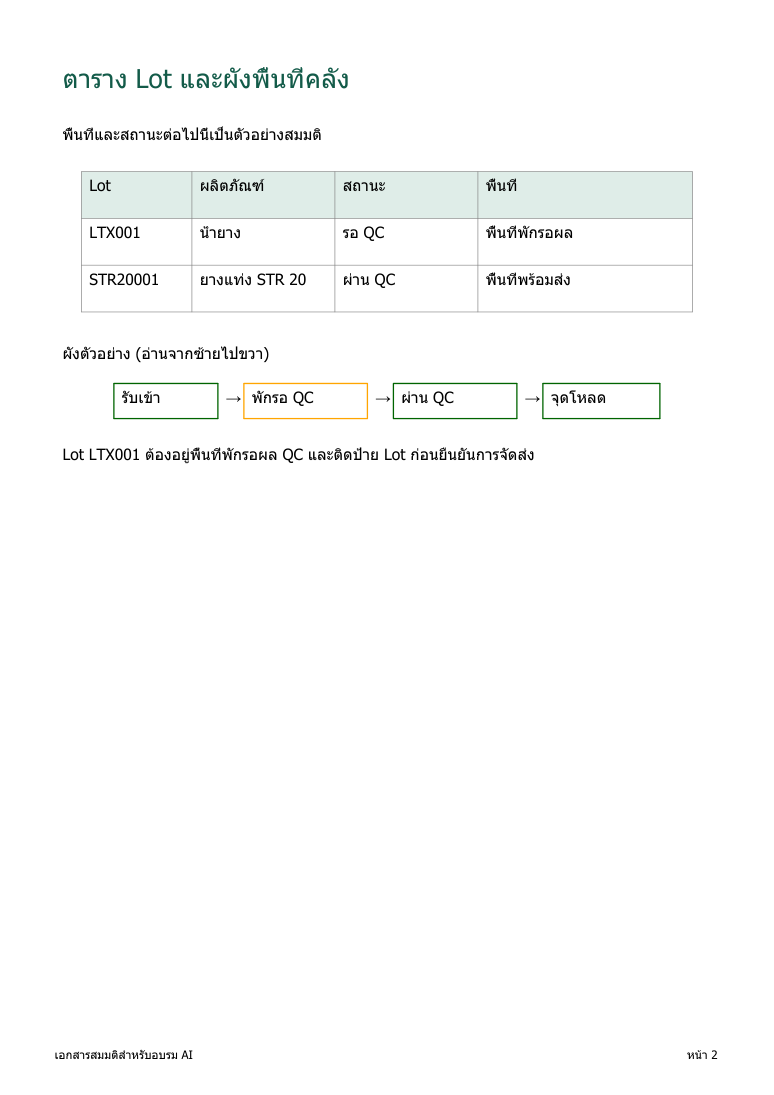

ระบบเลือกภาพอันดับแรกเสมอ คะแนนไม่ใช่ความน่าจะเป็น ต้องตรวจว่าภาพเกี่ยวข้องจริง


In [5]:
# โหลด index ที่บันทึกไว้ ไม่สร้างคำบรรยายหรือ embedding ของภาพซ้ำ
saved = json.loads((folder / "records.json").read_text(encoding="utf-8"))
records = saved["records"]
vectors = np.load(folder / "vectors.npy", allow_pickle=False)
for record in records:
    assert hashlib.sha256((folder / record["file"]).read_bytes()).hexdigest() == record["sha256"]

question = "ค้นภาพผังที่แสดงพื้นที่พักรอ QC และ Lot ที่อยู่ในพื้นที่นั้น"
query = client.embeddings.create(model=saved["embedding_model"], input=[question]).data[0].embedding
query = np.array(query)
scores = vectors @ (query / np.linalg.norm(query))
ranking = np.argsort(scores)[::-1]
for i in ranking:
    print(records[i]["file"], "คะแนน cosine:", round(float(scores[i]), 3))

best = records[int(ranking[0])]
selected_path = folder / best["file"]
print("ภาพที่ค้นพบ:", selected_path)
print("คำบรรยายที่ใช้ค้น:", best["caption"])
display(PILImage.open(selected_path))
print("ระบบเลือกภาพอันดับแรกเสมอ คะแนนไม่ใช่ความน่าจะเป็น ต้องตรวจว่าภาพเกี่ยวข้องจริง")

In [6]:
answer_question = "จากภาพที่ค้นพบ พื้นที่พักรอ QC อยู่ระหว่างพื้นที่ใด และ Lot ใดอยู่ในพื้นที่นั้น?"
response = client.responses.create(
    model=MODEL,
    input=[{"role": "user", "content": [
        {"type": "input_text", "text": answer_question + " ตอบภาษาไทยจากภาพนี้เท่านั้น ระบุชื่อไฟล์ " + best["file"] + " หากภาพไม่เกี่ยวข้องหรืออ่านไม่ชัดให้บอก ห้ามเดา"},
        image_content(selected_path),
    ]}], max_output_tokens=500,
)
print(response.output_text)

จากภาพไฟล์ image_2.png พื้นที่พักรอ QC อยู่ระหว่างพื้นที่รับเข้าและพื้นที่ผ่าน QC และ Lot ที่อยู่ในพื้นที่นั้นคือ Lot LTX001


## ลองทำด้วยตนเอง
1. เปลี่ยนคำถามค้นหาเป็นใบรับน้ำยางหรือการประสานงานขนส่ง แล้วรันเฉพาะเซลล์ค้นหาและตอบ
2. ตรวจคำบรรยายเทียบกับภาพต้นฉบับ มีรายละเอียดใดตกหล่นหรือผิด?
3. ถามเรื่องที่ไม่มีในภาพ เช่น ตารางวันหยุด ตรวจว่าระบบยังเลือกภาพอันดับแรกหรือไม่ และอธิบายว่าต้องมีเกณฑ์ปฏิเสธผลค้นหาอย่างไร
4. เปรียบเทียบคำตอบจากคำบรรยายกับคำตอบจากภาพ โดยเฉพาะตำแหน่งในผัง

ข้อจำกัด: เป็น caption-based retrieval; ไม่ใช่ joint image/text embedding และยังไม่มีเกณฑ์ relevance ที่ผ่านการประเมิน ค่า API: สร้างคำบรรยาย 1 request ต่อภาพ, embedding คำบรรยาย 1 batch, embedding คำถาม 1 request และตอบจากภาพ 1 request ต่อการค้นหา